In [1]:
#!pip install duckdb

In [2]:
import duckdb
import pandas as pd

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = duckdb.query("""
SELECT *
FROM read_csv_auto('data/*.csv', union_by_name=True)
""").df()

In [5]:
df.head()

,batch_date,test_name,swab_type,covid19_test_results,age,high_risk_exposure_occupation,high_risk_interactions,diabetes,chd,htn,cancer,asthma,copd,autoimmune_dis,smoker,temperature,pulse,sys,dia,rr,sats,rapid_flu_results,rapid_strep_results,ctab,labored_respiration,rhonchi,wheezes,days_since_symptom_onset,cough,cough_severity,fever,sob,sob_severity,diarrhea,fatigue,headache,loss_of_smell,loss_of_taste,runny_nose,muscle_sore,sore_throat,cxr_findings,cxr_impression,cxr_label,cxr_link,er_referral
0,2020-04-07,SARS COV 2 RNA RTPCR,Nasopharyngeal,Negative,58,True,<NA>,False,False,False,False,False,False,False,False,36.95,81.0,126.0,82.0,18.0,97.0,None,None,False,False,False,False,28.0,True,Severe,<NA>,False,None,False,False,False,False,False,False,False,False,None,None,None,None,False
1,2020-04-07,"SARS-CoV-2, NAA",Oropharyngeal,Negative,35,False,<NA>,False,False,False,False,False,False,False,False,36.75,77.0,131.0,86.0,16.0,98.0,None,None,False,False,False,False,NaN,True,Mild,False,False,None,False,False,False,False,False,False,False,False,None,None,None,None,False
2,2020-04-07,SARS CoV w/CoV 2 RNA,Oropharyngeal,Negative,12,<NA>,<NA>,False,False,False,False,False,False,False,False,36.95,74.0,122.0,73.0,17.0,98.0,None,None,<NA>,<NA>,<NA>,<NA>,NaN,False,None,<NA>,<NA>,None,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,None,None,None,None,False
3,2020-04-07,SARS COV 2 RNA RTPCR,Nasopharyngeal,Negative,46,True,True,False,False,False,False,False,False,False,False,36.75,66.0,128.0,76.0,18.0,100.0,None,None,False,False,<NA>,<NA>,3.0,True,Moderate,False,True,Moderate,False,True,False,False,False,False,False,True,None,None,None,None,False
4,2020-04-07,SARS CoV w/CoV 2 RNA,Nasopharyngeal,Negative,-1,False,<NA>,False,False,False,False,False,False,False,False,36.25,NaN,NaN,NaN,12.0,NaN,None,None,False,False,False,False,4.0,True,None,True,False,None,False,False,False,False,False,False,False,False,None,None,None,None,False


In [7]:
result = duckdb.query("""
SELECT *
FROM df
""").df()

In [11]:
result.head()

,batch_date,test_name,swab_type,covid19_test_results,age,high_risk_exposure_occupation,high_risk_interactions,diabetes,chd,htn,cancer,asthma,copd,autoimmune_dis,smoker,temperature,pulse,sys,dia,rr,sats,rapid_flu_results,rapid_strep_results,ctab,labored_respiration,rhonchi,wheezes,days_since_symptom_onset,cough,cough_severity,fever,sob,sob_severity,diarrhea,fatigue,headache,loss_of_smell,loss_of_taste,runny_nose,muscle_sore,sore_throat,cxr_findings,cxr_impression,cxr_label,cxr_link,er_referral
0,2020-04-07,SARS COV 2 RNA RTPCR,Nasopharyngeal,Negative,58,True,<NA>,False,False,False,False,False,False,False,False,36.95,81.0,126.0,82.0,18.0,97.0,None,None,False,False,False,False,28.0,True,Severe,<NA>,False,None,False,False,False,False,False,False,False,False,None,None,None,None,False
1,2020-04-07,"SARS-CoV-2, NAA",Oropharyngeal,Negative,35,False,<NA>,False,False,False,False,False,False,False,False,36.75,77.0,131.0,86.0,16.0,98.0,None,None,False,False,False,False,NaN,True,Mild,False,False,None,False,False,False,False,False,False,False,False,None,None,None,None,False
2,2020-04-07,SARS CoV w/CoV 2 RNA,Oropharyngeal,Negative,12,<NA>,<NA>,False,False,False,False,False,False,False,False,36.95,74.0,122.0,73.0,17.0,98.0,None,None,<NA>,<NA>,<NA>,<NA>,NaN,False,None,<NA>,<NA>,None,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,None,None,None,None,False
3,2020-04-07,SARS COV 2 RNA RTPCR,Nasopharyngeal,Negative,46,True,True,False,False,False,False,False,False,False,False,36.75,66.0,128.0,76.0,18.0,100.0,None,None,False,False,<NA>,<NA>,3.0,True,Moderate,False,True,Moderate,False,True,False,False,False,False,False,True,None,None,None,None,False
4,2020-04-07,SARS CoV w/CoV 2 RNA,Nasopharyngeal,Negative,-1,False,<NA>,False,False,False,False,False,False,False,False,36.25,NaN,NaN,NaN,12.0,NaN,None,None,False,False,False,False,4.0,True,None,True,False,None,False,False,False,False,False,False,False,False,None,None,None,None,False


In [13]:
sob_severity_query = """
SELECT DISTINCT sob_severity
FROM df
"""

In [14]:
sob_severity_df = duckdb.query(sob_severity_query).df()

In [15]:
sob_severity_df

,sob_severity
0,Moderate
1,Severe
2,Mild
3,None


In [20]:
test_results_sob_severity = """
SELECT 
    sob_severity,
    covid19_test_results,
    COUNT(*) AS n
FROM df
GROUP BY sob_severity, covid19_test_results
ORDER BY sob_severity, covid19_test_results
"""

In [21]:
df_result = duckdb.query(test_results_sob_severity).df()

In [22]:
df_result

,sob_severity,covid19_test_results,n
0,Mild,Negative,1548
1,Mild,Positive,56
2,Moderate,Negative,1070
3,Moderate,Positive,36
4,Severe,Negative,126
5,None,Negative,89938
6,None,Positive,1221


In [27]:
result = duckdb.query("""
SELECT 
    covid19_test_results,
    COUNT(*) AS n
FROM df
GROUP BY covid19_test_results
""").df()

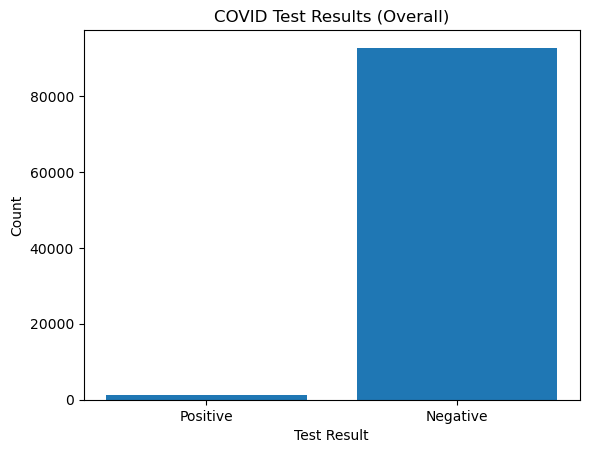

In [28]:
import matplotlib.pyplot as plt

plt.bar(result['covid19_test_results'], result['n'])

plt.xlabel('Test Result')
plt.ylabel('Count')
plt.title('COVID Test Results (Overall)')

plt.show()